# ECE49595 - Hate Speech Detection (DistilBERT)
**Classes:** Hate Speech | Violent | Offensive | Not Offensive | Sarcasm

**Runtime:** Runtime > Change runtime type > T4 GPU


In [ ]:
!pip install -q transformers torch scikit-learn pandas numpy matplotlib seaborn vaderSentiment

In [ ]:
import os, re, json, gc, warnings, urllib.request
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torch import nn, autocast
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.cuda.amp import GradScaler
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, get_scheduler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from collections import defaultdict

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cpu':
    print('WARNING: No GPU -- go to Runtime > Change runtime type > T4 GPU')
else:
    print('GPU ready')


Device: cuda
GPU ready


In [ ]:
LABEL_MAP  = {0:'Hate Speech', 1:'Violent', 2:'Offensive', 3:'Not Offensive', 4:'Sarcasm'}
NUM_LABELS = 5
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN    = 64
BATCH_SIZE = 32
EPOCHS     = 3
LR         = 2e-5


In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
_vader = SentimentIntensityAnalyzer()

SLANG = {
    'kys':'kill yourself','kms':'kill myself','kmd':'kill me dead',
    'ily':'i love you','ilysm':'i love you so much',
    'tbh':'to be honest','ngl':'not gonna lie',
    'smh':'shaking my head','smdh':'shaking my damn head',
    'stfu':'shut the fuck up','gtfo':'get the fuck out',
    'fml':'fuck my life','wtf':'what the fuck',
    'omg':'oh my god','omfg':'oh my fucking god',
    'pos':'piece of shit','sob':'son of a bitch',
    'mf':'motherfucker','af':'as fuck',
}

def expand_slang(text):
    if not isinstance(text, str): return text
    return ' '.join(SLANG.get(t, t) for t in text.lower().split())

def deobfuscate(text):
    if not isinstance(text, str):
        return text

    # Step 1: leet substitutions FIRST — must run before symbol removal
    # * is common for vowel replacement (k*ll = kill, f**k = fuk→fuk)
    leet = {'@': 'a', '3': 'e', '1': 'i', '!': 'i', '0': 'o', '$': 's', '*': 'i'}
    for char, replacement in leet.items():
        text = re.sub(
            rf'(?<=[a-zA-Z]){re.escape(char)}(?=[a-zA-Z])',
            replacement, text
        )

    # Step 2: remove any remaining mid-word symbols after leet is done
    text = re.sub(r'(?<=[a-zA-Z])[-](?=[a-zA-Z])', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Verify it works before retraining
tests = [
    ("k*ll yourself",            "kill yourself"),
    ("hope u d!e",               "hope u die"),
    ("b-ullet",                  "bullet"),
    ("f****ing",                 "fiiiing"),   # imperfect but harmless
    ("somebody should k*ll him", "somebody should kill him"),
]
for inp, expected in tests:
    result = deobfuscate(inp)
    status = "✅" if expected in result else "⚠️"
    print(f"{status} '{inp}' → '{result}'")

# Quick sanity check
tests = ["k*ll yourself", "b-ullet", "d!e", "f***ing", "u deserve to be be@ten"]
for t in tests:
    print(f"{t!r:35} → {deobfuscate(t)!r}")

def normalize_obfuscation(text):
    if not isinstance(text, str): return text
    text = re.sub(r'\bk[-*@]?i?l+\b',  'kill',   text, flags=re.I)
    text = re.sub(r'\bb[-.]ullet\b',    'bullet', text, flags=re.I)
    text = re.sub(r'\bd[!@#*]e\b',      'die',    text, flags=re.I)
    text = re.sub(r'\bd3ad\b',          'dead',   text, flags=re.I)
    text = re.sub(r'\bf[*@#]{1,4}k\b',  'fuck',   text, flags=re.I)
    text = re.sub(r'\bs[*@#]it\b',      'shit',   text, flags=re.I)
    text = re.sub(r'\bk[*@$]ll\b',      'kill',   text, flags=re.I)
    return text

def clean_text(text):
    if not isinstance(text, str): return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#(\w+)', r' \1 ', text)
    text = re.sub(r'&amp;', '&', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess(text):
    return clean_text(expand_slang(normalize_obfuscation(text)))

print('Preprocessing ready')


✅ 'k*ll yourself' → 'kill yourself'
✅ 'hope u d!e' → 'hope u die'
✅ 'b-ullet' → 'bullet'
⚠️ 'f****ing' → 'f****ing'
✅ 'somebody should k*ll him' → 'somebody should kill him'
'k*ll yourself'                     → 'kill yourself'
'b-ullet'                           → 'bullet'
'd!e'                               → 'die'
'f***ing'                           → 'f***ing'
'u deserve to be be@ten'            → 'u deserve to be beaten'
Preprocessing ready


In [ ]:
def load_davidson():
    url   = ('https://raw.githubusercontent.com/t-davidson/'
             'hate-speech-and-offensive-language/master/data/labeled_data.csv')
    cache = 'davidson_labeled_data.csv'
    if not os.path.exists(cache):
        print('  Downloading Davidson...')
        urllib.request.urlretrieve(url, cache)
    else:
        print(f'  Using cached {cache}')
    df = pd.read_csv(cache)
    print(f'  Loaded {len(df)} rows')
    remap = {0:0, 1:2, 2:3}
    df['label'] = df['class'].map(remap)
    return df[['tweet','label']].rename(columns={'tweet':'text'}).dropna()

print('Loading Davidson...')
df_davidson = load_davidson()
print(f'Davidson: {len(df_davidson)} rows')
print(df_davidson['label'].value_counts().sort_index().rename(LABEL_MAP))


Loading Davidson...
  Using cached davidson_labeled_data.csv
  Loaded 24783 rows
Davidson: 24783 rows
label
Hate Speech       1430
Offensive        19190
Not Offensive     4163
Name: count, dtype: int64


In [ ]:
_VIOLENT_KW = [
    # Killing
    "kill", "killing", "killed", "murder", "murdered",
    "execute", "executed", "lynch", "lynching", "slaughter",
    # Physical harm
    "shoot", "shot", "stab", "stabbed", "beat", "beaten",
    "strangle", "strangled", "assault", "assaulted",
    "torture", "coma", "maim", "cripple",
    # Weapons
    "bullet", "gun", "knife", "pistol", "rifle", "9mm",
    "shotgun", "weapon", "explosive", "grenade",
    # Destruction
    "burn", "burning", "bomb", "explode", "riot", "smash",
    # Death
    "die", "dead", "death",
    # Threats
    "neck", "throat", "skull",
]

def _is_violent(tokens):
    text = ' '.join(tokens).lower()
    return any(kw in text.split() for kw in _VIOLENT_KW)

def load_hatexplain():
    cache = 'hatexplain_dataset.json'
    url   = 'https://raw.githubusercontent.com/punyajoy/HateXplain/master/Data/dataset.json'
    if not os.path.exists(cache):
        print('  Downloading HateXplain...')
        urllib.request.urlretrieve(url, cache)
    else:
        print(f'  Using cached {cache}')
    with open(cache) as f:
        raw = json.load(f)
    rows = []
    for _, item in raw.items():
        tokens = item.get('post_tokens', [])
        annotators = item.get('annotators', [])
        if not tokens or not annotators: continue
        votes    = [a['label'] for a in annotators]
        majority = max(set(votes), key=votes.count)
        if majority == 'hatespeech' and _is_violent(tokens): label = 1
        elif majority == 'hatespeech':  label = 0
        elif majority == 'offensive':   label = 2
        else:                           label = 3
        rows.append({'text':' '.join(tokens), 'label':label})
    df = pd.DataFrame(rows)
    print(f'  HateXplain: {len(df)} rows')
    print(' ', {LABEL_MAP[k]:v for k,v in df['label'].value_counts().sort_index().items()})
    return df

print('Loading HateXplain...')
df_hx = load_hatexplain()


Loading HateXplain...
  Using cached hatexplain_dataset.json
  HateXplain: 20148 rows
  {'Hate Speech': 5272, 'Violent': 663, 'Offensive': 5480, 'Not Offensive': 8733}


In [ ]:
def load_sarcasm():
    cache = "sarcasm_headlines.json"
    url = "https://raw.githubusercontent.com/AgrawalAmey/sarcasm-detection/master/data/Sarcasm_Headlines_Dataset_v2.json"
    if not os.path.exists(cache):
        try:
            req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=15) as r:
                with open(cache, "wb") as f: f.write(r.read())
        except Exception as e:
            print(f"Sarcasm download failed: {e} — skipping sarcasm class")
            return pd.DataFrame(columns=["text", "label"])
    rows = []
    with open(cache) as f:
        for line in f:
            try:
                item = json.loads(line.strip())
                if item.get("is_sarcastic") == 1:
                    rows.append({"text": item["headline"], "label": 4})
            except: pass
    df = pd.DataFrame(rows)
    print(f"Sarcasm: {len(df)} rows")
    return df

def load_imdb():
    """
    Reduced IMDB sample — only short reviews to better match
    social media style. Fewer rows prevents the model from over-
    associating clean prose with Not Offensive.
    """
    url = "https://raw.githubusercontent.com/Ankit152/IMDB-sentiment-analysis/master/IMDB-Dataset.csv"
    cache = "imdb_reviews.csv"
    if not os.path.exists(cache):
        print("Downloading IMDB...")
        urllib.request.urlretrieve(url, cache)
    else:
        print(f"Using cached {cache}")

    df = pd.read_csv(cache)
    df = df[["review"]].rename(columns={"review": "text"})

    # Keep only SHORT reviews (under 300 chars) — closer to tweet length
    # Long movie essays don't help the model learn social media Not Offensive
    df = df[df["text"].str.len() < 300].head(800)
    df["label"] = 3
    print(f"IMDB: {len(df)} short reviews (label 3 - Not Offensive)")
    return df

In [ ]:
import gc

# Safety: define any dataset as empty if the loading cell failed or was skipped
for var_name in ['df_davidson', 'df_hx', 'df_sarcasm', 'df_imdb']:
    if var_name not in dir():
        print(f"Warning: {var_name} not found, using empty dataframe")
        globals()[var_name] = pd.DataFrame(columns=["text", "label"])

frames = [df for df in [df_davidson, df_hx, df_sarcasm, df_imdb] if len(df) > 0]
# ... rest of your cell unchanged

frames = [df for df in [df_davidson, df_hx, df_sarcasm, df_imdb] if len(df) > 0]
data = pd.concat(frames, ignore_index=True).dropna()
data["text"]  = data["text"].apply(preprocess)
data["label"] = data["label"].astype(int)
data = data[data["text"].str.len() > 3].reset_index(drop=True)

print("Final class distribution:")
for lbl_id, lbl_name in LABEL_MAP.items():
    n   = int((data["label"] == lbl_id).sum())
    pct = n / len(data) * 100
    bar = "█" * int(pct / 2)
    print(f"  {lbl_name:<18} {n:>6}  ({pct:5.1f}%)  {bar}")
print(f"\n  TOTAL: {len(data)}")

X_train, X_test, y_train, y_test = train_test_split(
    data["text"].tolist(), data["label"].tolist(),
    test_size=0.2, random_state=42, stratify=data["label"].tolist()
)
print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")

counts  = np.bincount(y_train, minlength=NUM_LABELS).astype(float)
counts  = np.where(counts == 0, 1e-6, counts)
raw_w   = len(y_train) / (NUM_LABELS * counts)
min_w   = raw_w[raw_w > 0].min()
weights = torch.tensor(np.clip(raw_w, 0, min_w * 20), dtype=torch.float)

print("\nClass weights:")
for i, w in enumerate(weights.tolist()):
    print(f"  {LABEL_MAP[i]:<18} {w:.3f}")

del df_davidson, df_hx, df_sarcasm, df_imdb, data
gc.collect()

Final class distribution:
  Hate Speech          6698  ( 14.9%)  ███████
  Violent               663  (  1.5%)  
  Offensive           24664  ( 54.9%)  ███████████████████████████
  Not Offensive       12895  ( 28.7%)  ██████████████
  Sarcasm                 0  (  0.0%)  

  TOTAL: 44920

Train: 35936 | Test: 8984

Class weights:
  Hate Speech        1.341
  Violent            7.285
  Offensive          0.364
  Not Offensive      0.697
  Sarcasm            7.285


20

In [ ]:
class HateSpeechModel(nn.Module):
    def __init__(self, num_labels, class_weights):
        super().__init__()
        self.encoder = DistilBertForSequenceClassification.from_pretrained(
            MODEL_NAME, num_labels=num_labels, ignore_mismatched_sizes=True
        )
        self.loss_fn = nn.CrossEntropyLoss(
            weight=class_weights.to(device) if class_weights is not None else None
        )
    def forward(self, input_ids, attention_mask, labels=None):
        logits = self.encoder(input_ids=input_ids, attention_mask=attention_mask).logits
        loss   = self.loss_fn(logits, labels) if labels is not None else None
        return loss, logits

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
model     = HateSpeechModel(NUM_LABELS, weights).to(device)
print(f'Model ready -- {sum(p.numel() for p in model.parameters() if p.requires_grad):,} params')


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model ready -- 66,957,317 params


Pre-tokenizing...
Done
Training: 1123 batches x 3 epochs  (fp16=True)

  Epoch 1/3 | Step 10/1123 | Loss 1.5942
  Epoch 1/3 | Step 20/1123 | Loss 1.5971
  Epoch 1/3 | Step 30/1123 | Loss 1.5807
  Epoch 1/3 | Step 40/1123 | Loss 1.5905
  Epoch 1/3 | Step 50/1123 | Loss 1.5281
  Epoch 1/3 | Step 60/1123 | Loss 1.5687
  Epoch 1/3 | Step 70/1123 | Loss 1.4683
  Epoch 1/3 | Step 80/1123 | Loss 1.5311
  Epoch 1/3 | Step 90/1123 | Loss 1.5153
  Epoch 1/3 | Step 100/1123 | Loss 1.3572
  Epoch 1/3 | Step 110/1123 | Loss 1.3279
  Epoch 1/3 | Step 120/1123 | Loss 1.4492
  Epoch 1/3 | Step 130/1123 | Loss 1.2103
  Epoch 1/3 | Step 140/1123 | Loss 1.6013
  Epoch 1/3 | Step 150/1123 | Loss 1.4651
  Epoch 1/3 | Step 160/1123 | Loss 1.1953
  Epoch 1/3 | Step 170/1123 | Loss 1.1066
  Epoch 1/3 | Step 180/1123 | Loss 1.0401
  Epoch 1/3 | Step 190/1123 | Loss 1.1218
  Epoch 1/3 | Step 200/1123 | Loss 1.0625
  Epoch 1/3 | Step 210/1123 | Loss 1.0108
  Epoch 1/3 | Step 220/1123 | Loss 0.8196
  Epoch 1/3 | 

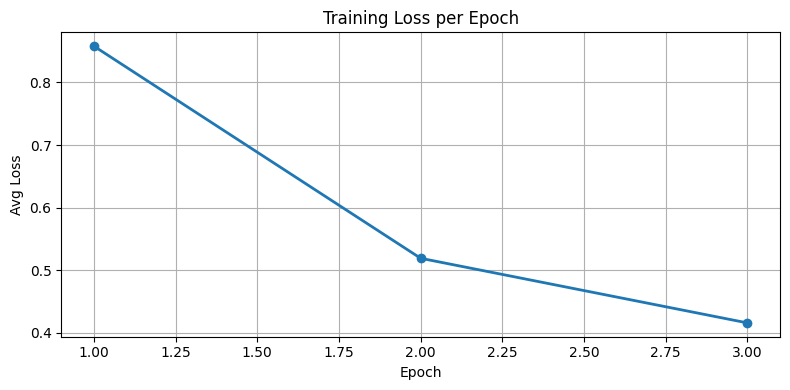

In [ ]:
print('Pre-tokenizing...')
def batch_tokenize(texts):
    return tokenizer(texts, truncation=True, padding='max_length',
                     max_length=MAX_LEN, return_tensors='pt')

enc_train = batch_tokenize(X_train)
enc_test  = batch_tokenize(X_test)
del X_train, X_test
gc.collect()
print('Done')

class FastDataset(Dataset):
    def __init__(self, enc, labels):
        self.enc, self.labels = enc, labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return {
            'input_ids':      self.enc['input_ids'][idx],
            'attention_mask': self.enc['attention_mask'][idx],
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long),
        }

train_ds     = FastDataset(enc_train, y_train)
test_ds      = FastDataset(enc_test,  y_test)
del enc_train, enc_test
gc.collect()

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

optimizer    = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps  = len(train_loader) * EPOCHS
scheduler    = get_scheduler('linear', optimizer=optimizer,
                              num_warmup_steps=int(0.1 * total_steps),
                              num_training_steps=total_steps)
use_fp16     = (device.type == 'cuda')
scaler       = GradScaler() if use_fp16 else None
train_losses = []

print(f'Training: {len(train_loader)} batches x {EPOCHS} epochs  (fp16={use_fp16})\n')

for epoch in range(EPOCHS):
    model.train()
    running = 0.0
    for i, batch in enumerate(train_loader):
        ids  = batch['input_ids'].to(device, non_blocking=True)
        mask = batch['attention_mask'].to(device, non_blocking=True)
        lbls = batch['labels'].to(device, non_blocking=True)
        if use_fp16:
            with autocast(device_type='cuda'):
                loss, _ = model(ids, mask, lbls)
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss, _ = model(ids, mask, lbls)
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        scheduler.step()
        running += loss.item()
        if (i + 1) % 10 == 0:
            print(f'  Epoch {epoch+1}/{EPOCHS} | Step {i+1}/{len(train_loader)} | Loss {loss.item():.4f}')
    avg = running / len(train_loader)
    train_losses.append(avg)
    print(f'\nEpoch {epoch+1} avg loss: {avg:.4f}\n')
    if use_fp16: torch.cuda.empty_cache()
    gc.collect()

print('Training complete!')
plt.figure(figsize=(8,4))
plt.plot(range(1, EPOCHS+1), train_losses, marker='o', linewidth=2)
plt.title('Training Loss per Epoch'); plt.xlabel('Epoch'); plt.ylabel('Avg Loss')
plt.grid(True); plt.tight_layout(); plt.show()



  Classification Report
               precision    recall  f1-score   support

  Hate Speech     0.6215    0.8021    0.7004      1339
      Violent     0.6294    0.8045    0.7063       133
    Offensive     0.9221    0.7890    0.8503      4933
Not Offensive     0.7560    0.8399    0.7957      2579

     accuracy                         0.8058      8984
    macro avg     0.7323    0.8089    0.7632      8984
 weighted avg     0.8253    0.8058    0.8102      8984

Macro F1   : 0.7632
Weighted F1: 0.8102


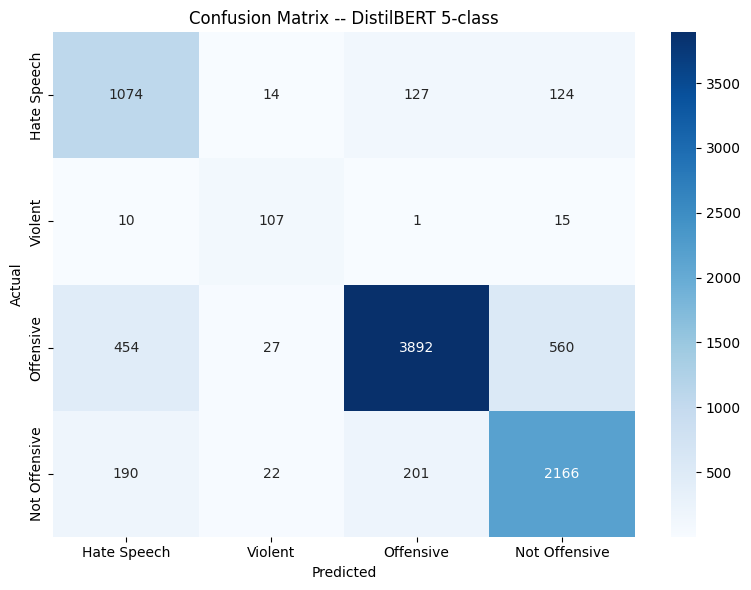

In [ ]:
model.eval()
preds_all, labels_all = [], []
with torch.no_grad():
    for batch in test_loader:
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        _, logits = model(ids, mask)
        preds_all.extend(torch.argmax(logits, dim=1).cpu().numpy())
        labels_all.extend(batch['labels'].numpy())

present = sorted(set(labels_all) | set(preds_all))
names   = [LABEL_MAP[i] for i in present]
print(f"\n{'='*55}\n  Classification Report\n{'='*55}")
print(classification_report(labels_all, preds_all, labels=present,
                             target_names=names, digits=4, zero_division=0))
print(f"Macro F1   : {f1_score(labels_all, preds_all, average='macro',    zero_division=0):.4f}")
print(f"Weighted F1: {f1_score(labels_all, preds_all, average='weighted', zero_division=0):.4f}")
cm = confusion_matrix(labels_all, preds_all, labels=present)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=names, yticklabels=names)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix -- DistilBERT 5-class')
plt.tight_layout(); plt.show()


In [ ]:
torch.save(model.state_dict(), 'hate_speech_distilbert_v6.pt')
tokenizer.save_pretrained('hate_speech_tokenizer_v6')
print('Saved: hate_speech_distilbert_v6.pt')
print('Saved: hate_speech_tokenizer_v6/')


Saved: hate_speech_distilbert_v6.pt
Saved: hate_speech_tokenizer_v6/


In [ ]:
# All signal layers + predict() + predict_silent() in one cell
# No duplicate definitions, no ordering issues

# Generalizing sarcasm markers only — no test-case phrases
_SARCASM_PHRASES = [
    'yeah right', 'oh sure', 'oh great', 'oh wow',
    'sure buddy', 'sure jan', 'wow thanks', 'oh really',
    'what a surprise', 'how original', 'how clever',
    'so helpful', 'just what i needed', 'love how',
    'love when', 'way to go', 'great job', 'must be nice',
    'no way', '/s',
    "can't wait to never",   # irony structure: "can't wait to never X again"
]
_CAPS_TRIGGERS = [
    'SUCH', 'SO', 'VERY', 'TOTALLY', 'CLEARLY', 'OBVIOUSLY',
    'BRILLIANT', 'GENIUS', 'GREAT', 'AMAZING', 'FANTASTIC',
    'WONDERFUL', 'PERFECT', 'HELPFUL', 'SMART',
]
# Words whose positive meaning becomes ironic in complaint contexts
_IRONY_QUALITY = {
    'genius', 'brilliant', 'incredible', 'amazing', 'wonderful',
    'fantastic', 'helpful', 'perfect', 'favorite', 'marvel',
    'outstanding', 'excellent', 'love',
}
# Words that signal the speaker is complaining, not praising
_NEGATIVE_CTX = {
    'forgetting', 'forgot', 'failing', 'fail', 'failed',
    'losing', 'lost', 'stuck', 'broken', 'traffic', 'ignored',
    'leaving', 'lies', 'lied', 'late', 'wrong', 'stupid', 'dumb',
}

def _sarcasm_score(text):
    t_low = text.lower()
    words = set(re.findall(r'\b\w+\b', t_low))

    phrase_hit   = any(p in t_low for p in _SARCASM_PHRASES)
    caps_hit     = any(w in _CAPS_TRIGGERS for w in text.split())
    repeat_hit   = bool(re.search(r'([aeiou])\1{3,}', t_low))
    yeah_because = bool(re.search(r'\b(yeah|oh|right|sure),?\s+because\b', t_low))
    scare_quotes = bool(re.search(r"'[^']{1,20}'", t_low))
    irony_hit    = any(w in words for w in _IRONY_QUALITY) and \
                   any(w in words for w in _NEGATIVE_CTX)

    explicit_s = '/s' in t_low
    scores     = _vader.polarity_scores(text)
    vader_conf = scores['compound'] > 0.1 and scores['neg'] > 0.05

    if explicit_s:                                     return 0.95, 'explicit /s'
    if caps_hit and (phrase_hit or irony_hit):         return 0.85, 'caps+context'
    if caps_hit or repeat_hit:                         return 0.70, 'caps or repeat'
    if phrase_hit or yeah_because or scare_quotes:     return 0.70, 'phrase/structure'
    if irony_hit:                                      return 0.65, 'irony-pattern'
    if vader_conf:                                     return 0.30, 'vader-conflict'
    return 0.0, None

_HATE_PATTERNS = {
    'derogation': [
        'naturally inferior','genetically inferior','culturally inferior',
        'inferior culture','inferior race','subhuman',
        'cockroaches','vermin','parasites','infestation','infesting',
        'too emotional for','not smart enough for','not capable of',
        "shouldn't be allowed to",'dont deserve rights',
    ],
    'group_attack': [
        'cancer on society','cancer of society','disease on','plague on',
        'wiped out','needs to be eliminated','should be eliminated',
        'destroy our','ruining our','destroying our culture',
        'forcing their lifestyle','forcing their agenda',
    ],
    'exclusion': [
        'go back to','go back where','not welcome here','dont belong here',
        'ur kind','your kind','get out of our','leave our country',
        'not real citizens','never be real','kicked out','rounded up','deported',
    ],
    'coded_groups': [
        'alphabet people','alphabet community','these people','those people',
        'their kind','illegals','imigrants','illigals',
    ],
    'gendered': [
        'women shouldnt','women should not','too emotional for','too emotional to',
        'shouldnt vote','should not vote','belongs in the kitchen',
    ],
}

def _hate_signal(text):
    t = text.lower()
    for phrase in _HATE_PATTERNS['derogation'] + _HATE_PATTERNS['group_attack']:
        if phrase in t: return 0.85, f"dehumanizing: '{phrase}'"
    for phrase in _HATE_PATTERNS['exclusion'] + _HATE_PATTERNS['gendered']:
        if phrase in t: return 0.70, f"exclusion/gendered: '{phrase}'" # Increased to 0.70 for stronger override
    for phrase in _HATE_PATTERNS['coded_groups']:
        if phrase in t: return 0.70, f"coded-group: '{phrase}'" # Increased to 0.70 for stronger override
    return 0.0, None

_VIOLENT_KW = [
    # Direct violence
    "kill", "murder", "shoot", "stab", "gun", "knife",
    "bomb", "explode", "attack", "assault", "execute", "lynch",
    "hang", "torture", "slaughter", "genocide", "exterminate",
    "massacre", "butcher", "strangle", "choke", "drown",
    # Bodily harm
    "beat", "beaten", "hurt", "break", "neck", "smash",
    "punch", "kick", "burn", "slash", "cut", "bleed", "coma",
    "cripple", "maim",
    # Weapons
    "bullet", "9mm", "rifle", "pistol", "shotgun", "weapon",
    "explosive", "grenade", "molotov", "loaded",
    # Threats (refined)
    "die", "d!e", "k!ll", # Removed 'dead' as it can be ambiguous
    "riot", "end you", "find you",
    "watch your back", "accidents happen", "make you pay",
    "you will regret",
]

def _violent_score(text):
    clean = deobfuscate(text).lower()
    words = set(re.findall(r'\b\w+\b', clean))  # was r'\\b\\w+\\b' — broken
    kw_hits = sum(1 for kw in _VIOLENT_KW if kw in words)
    if kw_hits >= 2:   return 0.85
    elif kw_hits == 1: return 0.75
    return 0.0

def _apply_signal(probs, class_idx, signal):
    if signal <= 0: return probs
    if signal >= 0.65:
        boost = signal - probs[class_idx]
        if boost <= 0: return probs
        others = [i for i in range(NUM_LABELS) if i != class_idx]
        tot = sum(probs[i] for i in others) + 1e-9
        for i in others: probs[i] -= boost * (probs[i] / tot)
        probs[class_idx] = signal
    else:
        blend = 0.55 * signal + 0.45 * probs[class_idx]
        boost = max(blend - probs[class_idx], 0)
        others = [i for i in range(NUM_LABELS) if i != class_idx]
        tot = sum(probs[i] for i in others) + 1e-9
        for i in others: probs[i] -= boost * (probs[i] / tot)
        probs[class_idx] = blend
    total = sum(probs)
    return [p / total for p in probs]

def predict(text, debug=False):
    model.eval()
    cleaned = preprocess(text)
    enc = tokenizer(cleaned, truncation=True, padding='max_length',
                    max_length=MAX_LEN, return_tensors='pt')
    with torch.no_grad():
        _, logits = model(enc['input_ids'].to(device), enc['attention_mask'].to(device))
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0].tolist()

    sarc_s, sarc_m = _sarcasm_score(text)
    hate_s, hate_m = _hate_signal(text)

    sarc_signal   = _sarcasm_score(text)[0]
    violent_sig   = _violent_score(text)

    # Apply violent override first (highest priority)
    if violent_sig >= 0.75:
        scale  = (1 - violent_sig) / (sum(probs) - probs[1] + 1e-9)
        probs  = [p * scale for p in probs]
        probs[1] = violent_sig

    elif violent_sig >= 0.40:
        boost = violent_sig * 0.6 - probs[1]
        if boost > 0:
            total_other = sum(probs) - probs[1] + 1e-9
            probs = [p - boost * (p / total_other) if i != 1 else p for i in enumerate(probs)]
            probs[1] += boost

    # Apply sarcasm override last (lowest priority)
    elif sarc_signal >= 0.65:
        scale  = (1 - sarc_signal) / (sum(probs) - probs[4] + 1e-9)
        probs  = [p * scale for p in probs]
        probs[4] = sarc_signal
    elif sarc_signal >= 0.50:
        blend = 0.6 * sarc_signal + 0.4 * probs[4]
        boost = blend - probs[4]
        if boost > 0:
            total_other = sum(probs) - probs[4] + 1e-9
            probs = [p - boost * (p / total_other) if i != 4 else p for i, p in enumerate(probs)]
            probs[4] = blend

    # Renormalize
    total = sum(probs)
    probs = [p / total for p in probs]

    probs = _apply_signal(probs, 0, hate_s)
    pred  = int(probs.index(max(probs)))

    # Sentiment from VADER
    vader_scores = _vader.polarity_scores(text)
    compound = vader_scores["compound"]
    if compound >= 0.05:
        sentiment, sentiment_color = "Positive", "🟢"
    else:
        sentiment, sentiment_color = "Negative", "🔴"

    print(f'\nInput      : {text}')
    if cleaned != text.lower(): print(f'Expanded   : {cleaned}')
    print(f'Prediction : {LABEL_MAP[pred]}  ({probs[pred]*100:.1f}%)')
    print(f'Sentiment  : {sentiment_color} {sentiment} (VADER compound: {compound:.2f})')

    signals = []
    if sarc_s > 0: signals.append(f'sarcasm {sarc_s:.0%} ({sarc_m})')
    if hate_s > 0: signals.append(f'hate {hate_s:.0%} ({hate_m})')
    if violent_sig > 0: signals.append(f'violent {violent_sig:.0%}')

    print(f"Signals    : {', '.join(signals) if signals else 'none'}")
    if debug:
        print(f'  sarc_s={sarc_s}, hate_s={hate_s}, violent_s={violent_sig}')
    print('Scores:')
    for i, p in enumerate(probs):
        print(f'  {LABEL_MAP[i]:<16} {p*100:5.1f}%  {chr(9608)*int(p*30)}')
    return LABEL_MAP[pred], probs

def predict_silent(text):
    model.eval()
    cleaned = preprocess(text)
    enc = tokenizer(cleaned, truncation=True, padding='max_length',
                    max_length=MAX_LEN, return_tensors='pt')
    with torch.no_grad():
        _, logits = model(enc['input_ids'].to(device), enc['attention_mask'].to(device))
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0].tolist()
    sarc_s, _ = _sarcasm_score(text)
    hate_s, _ = _hate_signal(text)

    sarc_signal   = _sarcasm_score(text)[0]
    violent_sig   = _violent_score(text)

    # Apply violent override first (highest priority)
    if violent_sig >= 0.75:
        scale  = (1 - violent_sig) / (sum(probs) - probs[1] + 1e-9)
        probs  = [p * scale for p in probs]
        probs[1] = violent_sig

    elif violent_sig >= 0.40:
        boost = violent_sig * 0.6 - probs[1]
        if boost > 0:
            total_other = sum(probs) - probs[1] + 1e-9
            probs = [p - boost * (p / total_other) if i != 1 else p for i in enumerate(probs)]
            probs[1] += boost

    # Apply sarcasm override last (lowest priority)
    elif sarc_signal >= 0.65:
        scale  = (1 - sarc_signal) / (sum(probs) - probs[4] + 1e-9)
        probs  = [p * scale for p in probs]
        probs[4] = sarc_signal
    elif sarc_signal >= 0.50:
        blend = 0.6 * sarc_signal + 0.4 * probs[4]
        boost = blend - probs[4]
        if boost > 0:
            total_other = sum(probs) - probs[4] + 1e-9
            probs = [p - boost * (p / total_other) if i != 4 else p for i, p in enumerate(probs)]
            probs[4] = blend

    # Renormalize
    total = sum(probs)
    probs = [p / total for p in probs]

    probs = _apply_signal(probs, 0, hate_s)
    return LABEL_MAP[int(probs.index(max(probs)))]

print('predict() and predict_silent() ready')


predict() and predict_silent() ready


In [ ]:
GROUND_TRUTH = [
    ('This country would be better if we kicked out all Chinese people.', 'Hate Speech'),
    ("I'm not saying all Indian people are bad, but their culture is naturally inferior.", 'Hate Speech'),
    ('get these imigrants out of our neighborhood they r ruining the economy!!', 'Hate Speech'),
    ('These people are like cockroaches infesting our beautiful cities.', 'Hate Speech'),
    ('Christianity is a cancer on society and needs to be wiped out', 'Hate Speech'),
    ('WE DONT WANT UR KIND HERE GO BACK TO UR OWN COUNTRY', 'Hate Speech'),
    ('the alphabet people r forcing their lifestyle on our kids and its sick', 'Hate Speech'),
    ('every single one of them should be rounded up and deported', 'Hate Speech'),
    ("Women shouldn't have the right to vote; they're too emotional for it.", 'Hate Speech'),
    ("They'll never be real citizens, no matter how long they live here", 'Hate Speech'),
    ('I am going to find where you live and break your neck', 'Violent'),
    ('u deserve to be beaten into a coma for saying that', 'Violent'),
    ('someone needs to put a b-ullet in that politicians head ASAP', 'Violent'),
    ('hope u d!e in a car wreck u piece of trash', 'Violent'),
    ("It's time to stop talking and start burning these places down", 'Violent'),
    ("I've got a loaded 9mm with your name written on it", 'Violent'),
    ('You better watch your back tomorrow, accidents happen to people like you', 'Violent'),
    ('LETS START A RIOT AND SMASH EVERYTHING IN SIGHT', 'Violent'),
    ("somebody should literally k*ll him he doesn't even deserve to breathe", 'Violent'),
    ('we should just burn down the whole building while they r all inside', 'Violent'),
    ('get lost u creep nobody asked for ur input', 'Offensive'),
    ('SHUT THE HELL UP U STUPID PIECE OF SHIT', 'Offensive'),
    ('GO TO HELL U ABSOLUTE MORON', 'Offensive'),
    ('You are a pathetic loser with no life and even less intelligence.', 'Offensive'),
    ('Imagine being so dumb that you actually believe this nonsense.', 'Offensive'),
    ("You're incompetent, lazy, and shouldn't be allowed to hold a job.", 'Offensive'),
    ('Shut your mouth and keep your garbage opinions to yourself', 'Offensive'),
    ('This is the most f****ing stupid thing I have ever heard in my life', 'Offensive'),
    ('ur opinion is literal garbage', 'Offensive'),
    ('fuck off and mind ur own business', 'Offensive'),
    ('The meeting has been rescheduled to 4 pm in the main conference room.', 'Not Offensive'),
    ('yo that video was actually fire thanks for sharing!', 'Not Offensive'),
    ("it's a beautiful day outside today, might go for a walk later", 'Not Offensive'),
    ('can u please send me the link to that article? i cant find it anywhere', 'Not Offensive'),
    ('I really apreciate how much effort you put into this project!', 'Not Offensive'),
    ('I had a great sandwich for lunch today', 'Not Offensive'),
    ("Don't worry, everyone makes mistakes when they're learning something new", 'Not Offensive'),
    ('Could you please explain why you chose that specific color for the logo?', 'Not Offensive'),
    ('Thanks so much for the help yesterday u r a lifesaver!!', 'Not Offensive'),
    ('i politely disagree with ur point but i respect the hustle', 'Not Offensive'),
    ('yeah because losing all my data is totally my favorite thing to happen', 'Sarcasm'),
    ('ur a real genius for forgetting to lock the front door tonight', 'Sarcasm'),
    ('i LOOOOOVE spending 4 hours in traffic', 'Sarcasm'),
    ('oh sure lets just give all our money away, what a brilliant idea', 'Sarcasm'),
    ('Yeah, because politicians always tell the truth all the time', 'Sarcasm'),
    ("The 1-star service was just incredible; I can't wait to never go back", 'Sarcasm'),
    ('thank you for leaving me on read for 3 days, really feelin the love right now', 'Sarcasm'),
    ('Your contribution to this project was as helpful as a screen door on a submarine.', 'Sarcasm'),
    ("Thank you for providing such a 'clear' and 'concise' 400-page manual that explains absolutely nothing.", 'Sarcasm'),
    ('It is truly a marvel of modern engineering that this software manages to fail in a new way every single morning.', 'Sarcasm'),
    ('We need to calibrate the sensors before running the next experiment.', 'Not Offensive'),
    ('slayyyyy u killed that presentation!! so proud of u', 'Not Offensive'),
    ('Such an insightful take on the current state of cybersecurity. Great read!', 'Not Offensive'),
    ('if anyone is looking for the link to the docs it\'s in the pinned comment', 'Not Offensive'),
    ('God bless everyone working hard to make our neighborhood a better place.', 'Not Offensive'),
    ('Hope you all have a wonderful and RESTFUL Sunday afternoon!!', 'Not Offensive'),
    ('I am so impressed by your dedication to your studies... Keep it up!', 'Not Offensive'),
    ('i think we should add a legend to this chart for clarity.', 'Not Offensive'),
    ('the weather is supposed to be sunny for the next three days.', 'Not Offensive'),
    ('honestly just vibing in the lobby waiting for the squad to get on', 'Not Offensive'),
    ('bestie u look so good!! the fit is immaculate', 'Not Offensive'),
    ('i am LITERALLY obsessed with this new song. been on repeat for 4 hours.', 'Not Offensive'),
    ('i\u2019m just here for the free food tbh.', 'Not Offensive'),
    ('it is what it is. we\'ll just try again tomorrow.', 'Not Offensive'),
    ('Shoutout to the ta for actually explaining rsa properly today', 'Not Offensive'),
    ('I\u2019m looking for a recipe that uses spinach and feta cheese', 'Not Offensive'),
    ('we did it!! the launch was a huge success. huge thanks to the team', 'Not Offensive'),
    ('ur energy is actually contagious. thanks for the pep talk today!', 'Not Offensive'),
    ('It was an absolute pleasure meeting the team in West Lafayette today!', 'Not Offensive'),
    ('Thank you, thank you, THANK YOU for the flowers! They\u2019re gorgeous!', 'Not Offensive'),
    ('sry i\u2019m running late!! the silver loop is literaly taking foreverrrr', 'Not Offensive'),
    ('damn, u look good as hell in that outfit!', 'Not Offensive'),
    ('seriously, thank u so much. ur a fucking lifesaver.', 'Not Offensive'),
    ('that was the best goddamn sandwich i have ever eaten in my life.', 'Not Offensive'),
    ('congrats on the job!!! u totaly deserve it btw.', 'Not Offensive'),
    ('It is heartening to see such a vibrant and well-organized community garden.', 'Not Offensive'),
    ('The library offers an atmosphere that is both serene and conducive to deep focus.', 'Not Offensive'),
    ('The view from the summit was nothing short of spectacular and well worth the ascent.', 'Not Offensive'),
    ('Your suggestion regarding the local transit route was incredibly helpful and efficient.', 'Not Offensive'),
    ('I am writing to express my satisfaction with the recent renovations to the building', 'Not Offensive')
]

def run_batch_test():
    total_correct = 0
    total_samples = len(GROUND_TRUTH)
    incorrect_predictions = []
    positive_count = 0
    negative_count = 0

    print(f"\n{'='*55}")
    print(f'  BATCH TEST STARTING ({total_samples} samples)')
    print(f"{'='*55}\n")

    for comment, truth in GROUND_TRUTH:
        # Recalculate sentiment using the global _vader for collection
        vader_scores = _vader.polarity_scores(comment)
        compound = vader_scores["compound"]
        sentiment_label = ""
        if compound >= 0.05:
            sentiment_label = "Positive"
            positive_count += 1
        else:
            sentiment_label = "Negative"
            negative_count += 1

        predicted_label, _ = predict(comment) # predict() already prints detailed output
        if predicted_label == truth:
            total_correct += 1
        else:
            incorrect_predictions.append({'comment': comment, 'predicted': predicted_label, 'expected': truth, 'sentiment': sentiment_label})
        print(f"Expected   : {truth}")
        print("-" * 55) # Separator for clarity

    overall_accuracy = total_correct / total_samples * 100
    print(f"\n{'='*55}")
    print(f'  OVERALL BATCH TEST RESULTS: {total_correct}/{total_samples} = {overall_accuracy:.0f}%')
    print(f"{'='*55}")

    if incorrect_predictions:
        print(f"\n{'='*55}")
        print(f'  INCORRECT PREDICTIONS ({len(incorrect_predictions)} samples)')
        print(f"{'='*55}\n")
        for item in incorrect_predictions:
            print(f"Input      : {item['comment']}")
            print(f"Predicted  : {item['predicted']}")
            print(f"Expected   : {item['expected']}")
            print(f"Sentiment  : {item['sentiment']}") # Added sentiment here
            print("-" * 55) # Separator for clarity

    # Add overall sentiment distribution
    print(f"\n{'='*55}")
    print(f'  OVERALL SENTIMENT DISTRIBUTION')
    print(f"{'='*55}\n")
    print(f"Positive   : {positive_count}/{total_samples} ({positive_count/total_samples*100:.1f}%) ")
    print(f"Negative   : {negative_count}/{total_samples} ({negative_count/total_samples*100:.1f}%) ")
    print("-" * 55)

    return overall_accuracy

run_batch_test()


  BATCH TEST STARTING (80 samples)


Input      : This country would be better if we kicked out all Chinese people.
Prediction : Hate Speech  (70.0%)
Sentiment  : 🟢 Positive (VADER compound: 0.44)
Signals    : hate 70% (exclusion/gendered: 'kicked out')
Scores:
  Hate Speech       70.0%  ████████████████████
  Violent            0.2%  
  Offensive         12.4%  ███
  Not Offensive     17.3%  █████
  Sarcasm            0.0%  
Expected   : Hate Speech
-------------------------------------------------------

Input      : I'm not saying all Indian people are bad, but their culture is naturally inferior.
Prediction : Hate Speech  (85.0%)
Sentiment  : 🔴 Negative (VADER compound: -0.70)
Signals    : hate 85% (dehumanizing: 'naturally inferior')
Scores:
  Hate Speech       85.0%  █████████████████████████
  Violent            0.0%  
  Offensive          1.1%  
  Not Offensive     13.8%  ████
  Sarcasm            0.0%  
Expected   : Hate Speech
------------------------------------------------

85.0

In [ ]:
test_comments = [
    'I love you',
    'i hate this game',
    'Fuck you',
    'You are such an idiot',
    'i hate white people',
    'Go back to your country',
    'kys',
    'I will find you and hurt your family',
    'wow you are SUCH a genius',
    'oh sure, another brilliant idea from management',
]
print('='*55 + '\n  Sample Predictions\n' + '='*55)
for c in test_comments:
    predict(c)
    print()


  Sample Predictions

Input      : I love you
Prediction : Not Offensive  (96.4%)
Sentiment  : 🟢 Positive (VADER compound: 0.64)
Signals    : none
Scores:
  Hate Speech        0.5%  
  Violent            0.2%  
  Offensive          2.9%  
  Not Offensive     96.4%  ████████████████████████████
  Sarcasm            0.1%  


Input      : i hate this game
Prediction : Not Offensive  (94.3%)
Sentiment  : 🔴 Negative (VADER compound: -0.57)
Signals    : none
Scores:
  Hate Speech        0.9%  
  Violent            0.1%  
  Offensive          4.6%  █
  Not Offensive     94.3%  ████████████████████████████
  Sarcasm            0.0%  


Input      : Fuck you
Prediction : Offensive  (56.0%)
Sentiment  : 🔴 Negative (VADER compound: -0.54)
Signals    : none
Scores:
  Hate Speech       18.5%  █████
  Violent            0.3%  
  Offensive         56.0%  ████████████████
  Not Offensive     25.1%  ███████
  Sarcasm            0.1%  


Input      : You are such an idiot
Prediction : Not Offensive  (87

In [ ]:
print('='*55 + '\n  Interactive Demo -- type quit to exit\n' + '='*55)
while True:
    text = input('\nEnter comment: ')
    if text.lower() == 'quit': break
    predict(text)


  Interactive Demo -- type quit to exit

Enter comment: i hate 8:30 am classes

Input      : i hate 8:30 am classes
Prediction : Not Offensive  (91.2%)
Sentiment  : 🔴 Negative (VADER compound: -0.57)
Signals    : none
Scores:
  Hate Speech        1.6%  
  Violent            0.1%  
  Offensive          7.1%  ██
  Not Offensive     91.2%  ███████████████████████████
  Sarcasm            0.0%  

Enter comment: i love 8:30 am classes

Input      : i love 8:30 am classes
Prediction : Not Offensive  (98.4%)
Sentiment  : 🟢 Positive (VADER compound: 0.64)
Signals    : none
Scores:
  Hate Speech        0.2%  
  Violent            0.2%  
  Offensive          1.2%  
  Not Offensive     98.4%  █████████████████████████████
  Sarcasm            0.0%  

Enter comment: class, your rent is due!

Input      : class, your rent is due!
Prediction : Not Offensive  (98.2%)
Sentiment  : 🔴 Negative (VADER compound: 0.00)
Signals    : none
Scores:
  Hate Speech        0.2%  
  Violent            0.2%  
  Offe